In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROCESSED_DIR = Path("data/processed")
INTERIM_DIR = Path("data/interim")
TABLES_DIR = Path("outputs/tables")
FIGURES_DIR = Path("outputs/figures")

for folder in [TABLES_DIR, FIGURES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

priced = pd.read_csv(PROCESSED_DIR / "pokemon_priced_cards.csv", dtype={"Card Number": str}, low_memory=False)
unpriced = pd.read_csv(PROCESSED_DIR / "pokemon_unpriced_cards.csv", dtype={"Card Number": str}, low_memory=False)
full = pd.read_csv(INTERIM_DIR / "pokemon_cleaned_full.csv", dtype={"Card Number": str}, low_memory=False)

print("Priced:", priced.shape)
print("Unpriced:", unpriced.shape)
display(priced.head())

Priced: (35732, 11)
Unpriced: (4723, 10)


,Collection,Set Name,Card Number,Card Name,Rarity,Card Type,Pokémon Type,HP,Illustrator,Value,Log_Value
0,1st Edition,Base Set,1,Alakazam,★H,Stage 2,Psychic,80.0,Ken Sugimori,799.99,6.685848
1,1st Edition,Base Set,2,Blastoise,★H,Stage 2,Water,100.0,Ken Sugimori,1759.99,7.473631
2,1st Edition,Base Set,3,Chansey,★H,Basic,Colorless,120.0,Ken Sugimori,419.99,6.042609
3,1st Edition,Base Set,4,Charizard,★H,Stage 2,Fire,120.0,Mitsuhiro Arita,7999.99,8.987321
4,1st Edition,Base Set,5,Clefairy,★H,Basic,Colorless,40.0,Ken Sugimori,439.99,6.089022


In [2]:
missing = pd.DataFrame({
    "missing_count": full.isna().sum(),
    "missing_pct": full.isna().mean() * 100,
    "dtype": full.dtypes.astype(str)
}).sort_values("missing_pct", ascending=False)

target_summary = priced[["Value", "Log_Value"]].describe(
    percentiles=[.01, .05, .10, .25, .50, .75, .90, .95, .99]
)

display(missing.head(25))
display(target_summary)
missing.to_csv(TABLES_DIR / "eda_missing_profile.csv", encoding="utf-8-sig")
target_summary.to_csv(TABLES_DIR / "eda_target_summary.csv", encoding="utf-8-sig")

,missing_count,missing_pct,dtype
HP,7997,19.767643,float64
Illustrator,7,0.017303,str
Set Name,0,0.000000,str
Collection,0,0.000000,str
Card Number,0,0.000000,str
Card Name,0,0.000000,str
Card Type,0,0.000000,str
Rarity,0,0.000000,str
Pokémon Type,0,0.000000,str
Value,0,0.000000,float64


,Value,Log_Value
count,35732.000000,35732.000000
mean,10.022121,1.015882
std,79.383694,1.132413
min,0.040000,0.039221
1%,0.200000,0.182322
5%,0.200000,0.182322
10%,0.280000,0.246860
25%,0.310000,0.270027
50%,0.620000,0.482426
75%,3.030000,1.393766


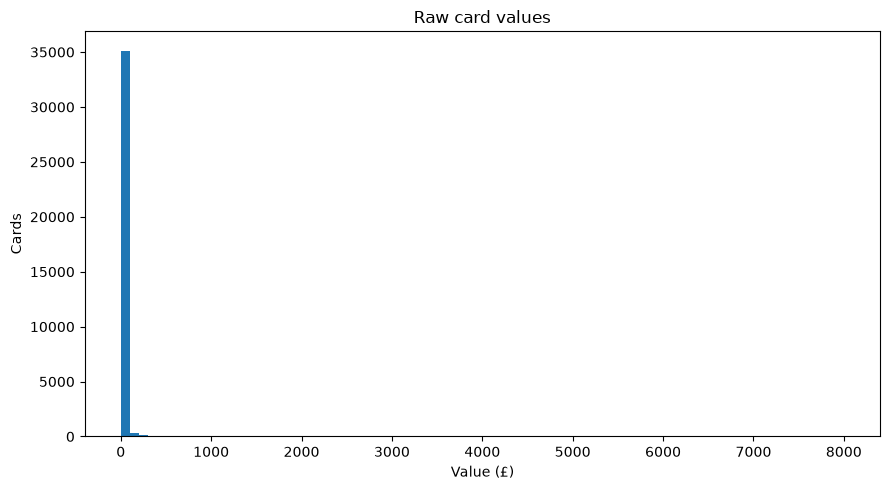

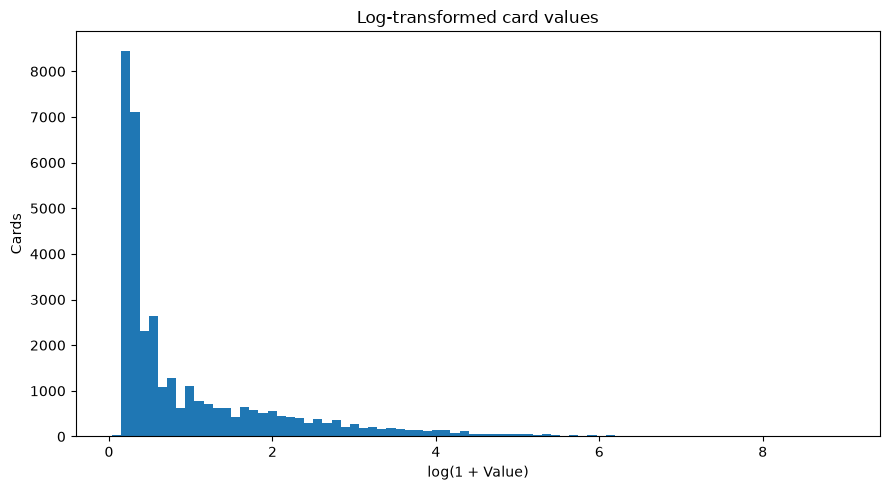

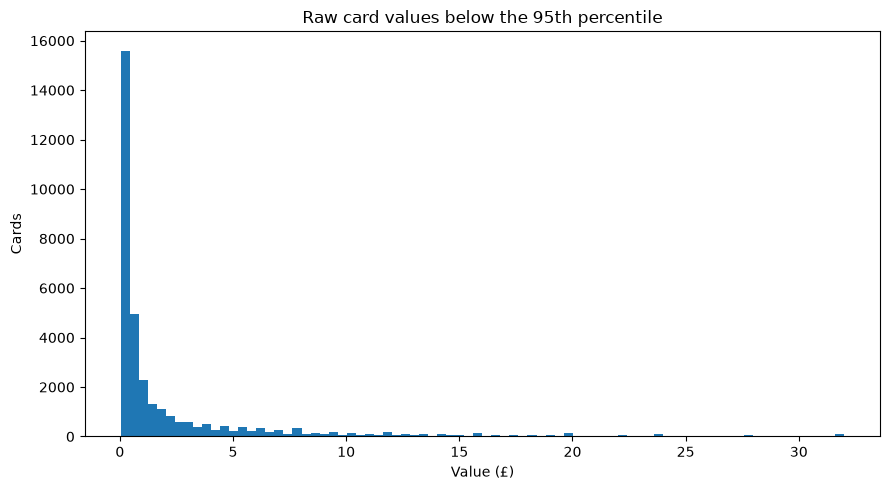

In [3]:
q95 = priced["Value"].quantile(.95)
histograms = [
    (priced["Value"], "Value (£)", "Raw card values", "eda_raw_value_distribution.png"),
    (priced["Log_Value"], "log(1 + Value)", "Log-transformed card values",
     "eda_log_value_distribution.png"),
    (priced.loc[priced["Value"] <= q95, "Value"], "Value (£)",
     "Raw card values below the 95th percentile", "eda_raw_value_zoomed.png")
]

for values, label, title, filename in histograms:
    plt.figure(figsize=(9, 5))
    plt.hist(values, bins=80)
    plt.xlabel(label)
    plt.ylabel("Cards")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, dpi=200)
    plt.show()

In [4]:
price_bins = [0, 1, 5, 10, 25, 50, 100, 250, 500, np.inf]
price_labels = ["£0-1", "£1-5", "£5-10", "£10-25", "£25-50", "£50-100", "£100-250", "£250-500", "£500+"]
priced["Price_Band"] = pd.cut(priced["Value"], price_bins, labels=price_labels, include_lowest=True)

price_bands = priced["Price_Band"].value_counts().sort_index().rename("card_count").to_frame()
price_bands["percentage"] = price_bands["card_count"] / len(priced) * 100

top_cols = ["Card Name", "Set Name", "Collection", "Card Type", "Rarity", "Card Number", "HP", "Value"]
top_cards = priced.sort_values("Value", ascending=False)[top_cols].head(30)

display(price_bands)
display(top_cards)
price_bands.to_csv(TABLES_DIR / "eda_price_bands.csv", encoding="utf-8-sig")
top_cards.to_csv(TABLES_DIR / "eda_top_30_cards.csv", index=False, encoding="utf-8-sig")

,card_count,percentage
Price_Band,,
£0-1,21380,59.834322
£1-5,7518,21.039964
£5-10,2578,7.214821
£10-25,2099,5.874286
£25-50,945,2.644688
£50-100,610,1.707153
£100-250,377,1.055077
£250-500,142,0.397403
£500+,83,0.232285


,Card Name,Set Name,Collection,Card Type,Rarity,Card Number,HP,Value
3,Charizard,Base Set,1st Edition,Stage 2,★H,4,120.0,7999.99
6096,Rayquaza ☆,EX Deoxys,Unlimited,Basic,☆,107,90.0,4399.99
3471,Charizard,Skyridge,Unlimited,Stage 2,★S,146,110.0,4159.99
8210,Umbreon ☆,POP Series 5,Unlimited,Basic,☆,17,70.0,2639.99
8209,Espeon ☆,POP Series 5,Unlimited,Basic,☆,16,70.0,2479.99
2260,Shining Charizard,Neo Destiny,1st Edition,Basic,⁂,107,100.0,2399.99
8247,Championship Arena,Nintendo Black Star Promos,Black Star Promo,Stadium,—,028,NaN,2399.99
1060,Dark Dragonite,Team Rocket,Error (1st Edition Non Holo),Stage 2,★,5,70.0,2079.99
7891,Charizard ☆ δ,EX Dragon Frontiers,Unlimited,Basic,☆,100,90.0,1999.99
1,Blastoise,Base Set,1st Edition,Stage 2,★H,2,100.0,1759.99


,Rarity,card_count,median_value,mean_value,median_log_value
34,★ex,162,61.19,89.208025,4.130191
22,★L,22,53.79,50.585909,4.002968
23,★P,28,17.63,24.712857,2.924494
5,​★★,104,17.59,36.542788,2.922624
26,★S,339,11.99,78.246195,2.564180
25,★R,309,7.99,17.719126,2.196113
6,​★★★,61,7.99,11.648852,2.196113
33,★U,758,7.39,24.163074,2.127029
20,★GGU,32,7.19,11.502500,2.098120
38,☆SH,55,6.55,21.910000,2.021548


,Card Type,card_count,median_value,mean_value,median_log_value
6,LEGEND,22,53.790,50.585909,4.002968
7,Level-Up,87,23.670,34.838391,3.205588
18,Tag Team,133,18.870,42.351278,2.989211
8,Mega,117,11.590,23.785556,2.532903
1,Baby,36,8.670,16.478611,2.268609
23,VSTAR,107,3.960,9.543738,1.601406
22,VMAX,226,3.745,22.035575,1.556558
12,Rocket's Secret Machine,26,3.670,7.522308,1.541012
0,BREAK,44,2.110,3.662727,1.134540
19,Technical Machine,43,1.670,4.719302,0.982078


,Set Name,card_count,median_value,mean_value,median_log_value
78,Legendary Collection,228,31.99,51.101096,3.496204
100,Nintendo Black Star Promos,61,21.99,101.571148,3.135059
12,Best of Game,23,18.39,35.750000,2.964757
142,Skyridge,332,17.27,74.933223,2.905222
108,POP Series 5,26,14.79,225.137692,2.756481
71,HGSS Black Star Promos,35,12.39,61.919143,2.594508
163,Wizards Black Star Promos,63,11.91,66.321429,2.558002
27,DP Black Star Promos,76,11.07,46.366842,2.489794
107,POP Series 4,24,10.67,37.432917,2.456969
106,POP Series 3,24,9.71,21.146667,2.369158


,Collection,card_count,median_value,mean_value,median_log_value
208,Stamp (Regional Championships Staff),27,47.990,89.397407,3.891616
204,Stamp (Prerelease Staff),112,26.390,62.708661,3.310178
224,Stamp (Winner),20,23.990,36.794000,3.218476
51,Error (Holo Bleed),44,15.990,39.837045,2.831515
113,Special Set,89,9.590,38.090000,2.359910
215,Stamp (Snowflake),48,7.995,14.398542,2.196669
343,Yellow A Alternate Art,41,6.390,13.816098,2.000128
0,1st Edition,941,5.590,55.475515,1.885553
210,Stamp (Regional Championships),38,4.590,10.277895,1.717872
213,Stamp (Series),24,3.950,5.226667,1.599355


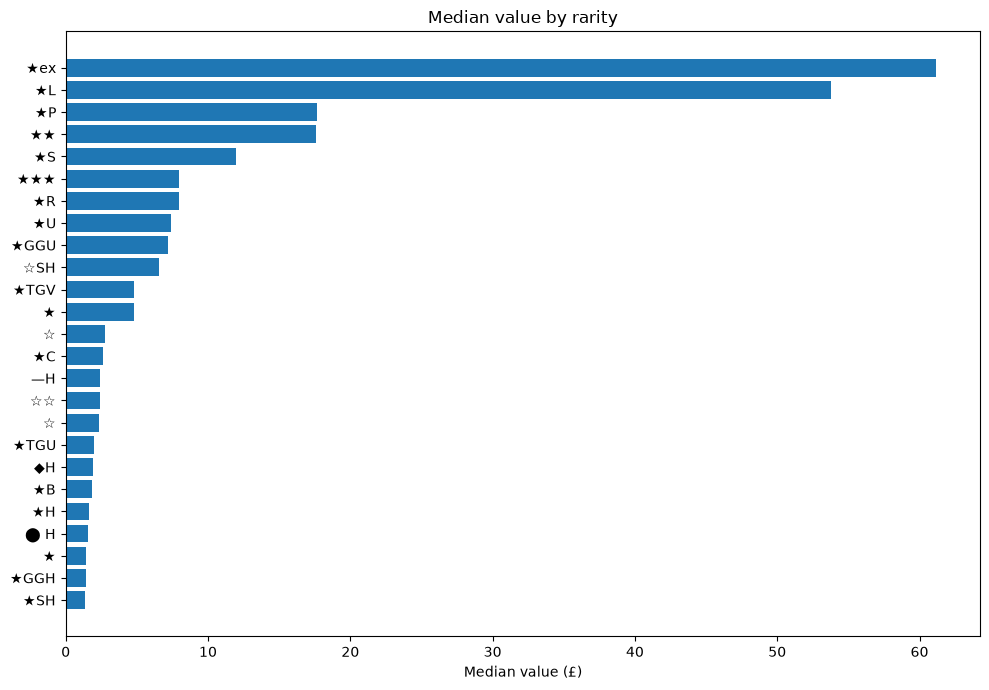

In [5]:
def value_by(column, minimum=20):
    out = priced.groupby(column, dropna=False).agg(
        card_count=("Value", "size"),
        median_value=("Value", "median"),
        mean_value=("Value", "mean"),
        median_log_value=("Log_Value", "median")
    ).reset_index()
    return out[out["card_count"] >= minimum].sort_values("median_value", ascending=False)

for column in ["Rarity", "Card Type", "Set Name", "Collection"]:
    table = value_by(column)
    display(table.head(25))
    table.to_csv(TABLES_DIR / f"eda_value_by_{column.lower().replace(' ', '_')}.csv", index=False, encoding="utf-8-sig")

rarity_plot = value_by("Rarity").head(25).sort_values("median_value")
plt.figure(figsize=(10, 7))
plt.barh(rarity_plot["Rarity"].astype(str), rarity_plot["median_value"])
plt.xlabel("Median value (£)")
plt.title("Median value by rarity")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_median_value_by_rarity.png", dpi=200)
plt.show()

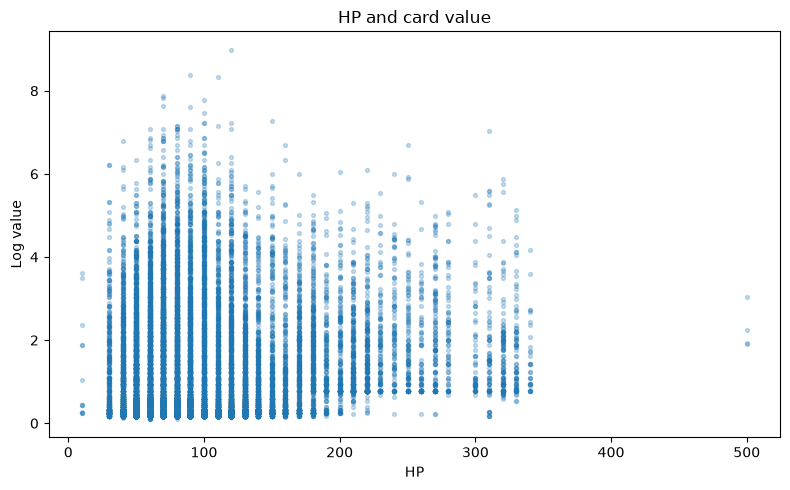

,status,card_count
0,Priced,35732
1,Unpriced,4723


In [6]:
hp = pd.to_numeric(priced["HP"], errors="coerce")
plt.figure(figsize=(8, 5))
plt.scatter(hp, priced["Log_Value"], alpha=.25, s=8)
plt.xlabel("HP")
plt.ylabel("Log value")
plt.title("HP and card value")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eda_hp_vs_log_value.png", dpi=200)
plt.show()

status = pd.DataFrame({
    "status": ["Priced", "Unpriced"],
    "card_count": [len(priced), len(unpriced)]
})
display(status)
status.to_csv(TABLES_DIR / "eda_priced_vs_unpriced.csv", index=False, encoding="utf-8-sig")

In [7]:
eda_summary = pd.DataFrame([{
    "priced_rows": len(priced),
    "unpriced_rows": len(unpriced),
    "median_value": priced["Value"].median(),
    "mean_value": priced["Value"].mean(),
    "value_95th_percentile": priced["Value"].quantile(.95),
    "value_99th_percentile": priced["Value"].quantile(.99),
    "maximum_value": priced["Value"].max(),
    "log_value_mean": priced["Log_Value"].mean(),
    "log_value_std": priced["Log_Value"].std()
}])

eda_summary.to_csv(TABLES_DIR / "eda_summary.csv", index=False, encoding="utf-8-sig")
display(eda_summary.T)

,0
priced_rows,35732.000000
unpriced_rows,4723.000000
median_value,0.620000
mean_value,10.022121
value_95th_percentile,31.990000
value_99th_percentile,159.990000
maximum_value,7999.990000
log_value_mean,1.015882
log_value_std,1.132413
